In [49]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import sys
sys.path.append("../") 
import WRFDomainLib
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.rcParams["font.family"] = "Sans-Serif"
import datetime

#import xarray as xr

# Example usage
cmap = "BrBG"#inferno_white()
from netCDF4 import Dataset, num2date

import os

WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)
    

In [50]:
# -------- CONFIGURATION --------
variable = 't'  # 't', 'pr', or 'wind'
period = 'rcp45'
domain = 'CanESM2'
out_file = f'/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/seasonal_deltas_and_pvals_{variable}_{period}_{domain}.npz'

basepath = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/gridded_model_daily/CanESM2_raw/'
if variable=='wind':
   var='sfcWind'
   filename=variable+'_'
elif variable=='t':
   var = 'tas'
   filename=var+'_'
elif variable=='pr':
   filename=variable+'_'
   var = variable
# -------- HELPER FUNCTIONS --------

def load_data(path, varname):
    nc = Dataset(path, 'r')
    data = nc.variables[varname][:]
    times = nc.variables['time'][:]
    time_units = nc.variables['time'].units
    try:
        time_calendar = nc.variables['time'].calendar
    except AttributeError:
        time_calendar = "standard"

    # decode times properly
    datetimes = num2date(times, units=time_units, calendar=time_calendar)

    lat = nc.variables['lat'][:]
    lon = nc.variables['lon'][:]
    nc.close()
    return data, datetimes, lat, lon

In [51]:
hist_path = os.path.join(basepath, f"{filename}hist.nc")
fut_path = os.path.join(basepath, f"{filename}{period}.nc")

data_hist, time_hist,lat,lon = load_data(hist_path, var)
data_fut, time_fut,lat,lon = load_data(fut_path, var)


In [52]:
import numpy as np

def monthly_climatology(data, datetimes):
    """
    Compute monthly climatology.

    Parameters
    ----------
    data : np.ndarray
        Array with time as the first dimension: (time, ...).
    datetimes : array-like
        Sequence of datetime objects corresponding to time dimension.

    Returns
    -------
    clim : np.ndarray
        Monthly climatology with shape (12, ...),
        where index 0 = January, ..., 11 = December.
    """
    data = np.asarray(data)

    # extract month (1–12) from datetimes
    months = np.array([dt.month for dt in datetimes])

    clim = np.full((12,) + data.shape[1:], np.nan)

    for m in range(1, 13):
        idx = months == m
        if np.any(idx):
            clim[m-1, ...] = np.nanmean(data[idx, ...], axis=0)

    return clim


In [53]:
def group_by_season(data, time, season):
    season_months = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }
    season_vals = {}
    for i, date in enumerate(time):
        if date.month in season_months[season]:
            year = date.year if date.month != 12 else date.year + 1
            if year not in season_vals:
                season_vals[year] = []
            season_vals[year].append(data[i])
    result = []
    for year, vals in sorted(season_vals.items()):
        stacked = np.stack(vals)
        result.append((year, stacked.mean(axis=0)))
    return result

def compute_seasonal_means(data, time):
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    results = {}
    for season in seasons:
        results[season] = group_by_season(data, time, season)
    return results


In [54]:
clim_hist=monthly_climatology(data_hist, time_hist).mean(axis=(1,2))
clim_fut=monthly_climatology(data_fut, time_fut).mean(axis=(1,2))

In [55]:
np.shape(clim_hist)

(12,)

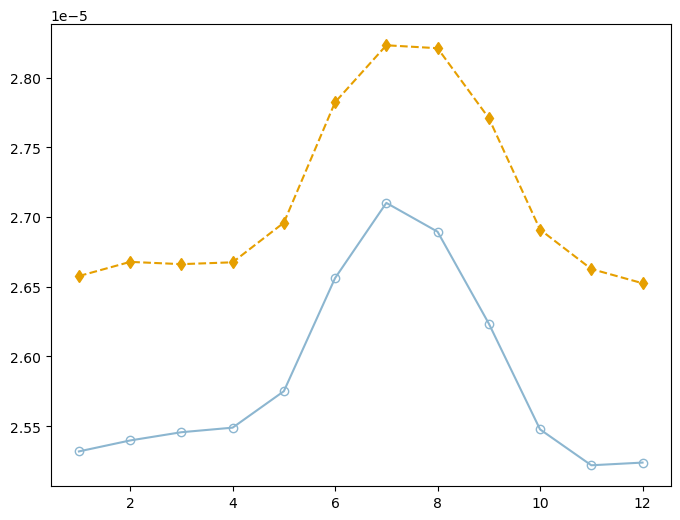

In [56]:
# Ocean colors
color3 = '#364B9A'  # Ocean (historical) — deep blue
color2 = '#8CB6D0'  # Ocean (RCP8.5) — light muted blue

# Land colors
color4 = '#D55E00'  # Land (historical) — warm reddish-orange
color1 = '#E69F00'  # Land (RCP8.5) — golden yellow

plt.figure(figsize=(8,6))
ax = plt.subplot(1, 1, 1)
#om, lm=getaverages('t', period, domain)
at=0.01
bt=.95

months = np.arange(1, 13)
plt.plot(months, clim_hist, label='hist', marker='o', color=color2, markerfacecolor='none')
plt.plot(months, clim_fut, label='fut', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)


In [57]:
peak_h=np.max(clim_hist);
peak_h
trough_h=np.min(clim_hist)
amplitude_h=peak_h-trough_h
print(amplitude_h)
peak_f=np.max(clim_fut);

trough_f=np.min(clim_fut)
amplitude_f=peak_f-trough_f
print(amplitude_f)

1.8814138882206977e-06
1.7062380643762367e-06


In [62]:
var='pr'
data_hist, time_hist,lat,lon = load_data(hist_path, var)
data_fut, time_fut,lat,lon = load_data(fut_path, var)
clim_hist=monthly_climatology(data_hist, time_hist).mean(axis=(1,2))
clim_fut=monthly_climatology(data_fut, time_fut).mean(axis=(1,2)) 
print('hist', data_hist.max() - data_hist.min())
print('fut', data_fut.max() - data_fut.min())

hist 0.0043870825
fut 0.0042127525


In [70]:
# -------- CONFIGURATION --------
variable = 't'  # 't', 'pr', or 'wind'
period = 'rcp85'
domain = 'CanESM2'

basepath = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/gridded_model_daily/CanESM2_raw/'
if variable=='wind':
   var='sfcWind'
   filename=variable+'_'
elif variable=='t':
   var = 'tas'
   filename=var+'_'
elif variable=='pr':
   filename=variable+'_'
   var = variable

hist_path = os.path.join(basepath, f"{filename}hist.nc")
fut_path = os.path.join(basepath, f"{filename}{period}.nc")

data_hist, time_hist,lat,lon = load_data(hist_path, var)
data_fut, time_fut,lat,lon = load_data(fut_path, var)
clim_hist_ESM=monthly_climatology(data_hist, time_hist).mean(axis=(1,2))
clim_fut_ESM45=monthly_climatology(data_fut, time_fut).mean(axis=(1,2)) 
t_ESM=[clim_hist_ESM, clim_fut_ESM45]
print('hist', data_hist.max() - data_hist.min())
print('fut', data_fut.max() - data_fut.min())

hist 142.69348
fut 146.17264


In [69]:
# -------- CONFIGURATION --------
variable = 't'  # 't', 'pr', or 'wind'
period = 'rcp85'
domain = 'CanRCM4'
basepath = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/gridded_model_daily/CanRCM4/'
if variable=='wind':
   var='sfcWind'
   filename=variable+'_NAM22_'
elif variable=='t':
   var = 'tas'
   filename=var+'_NAM22_'
elif variable=='pr':
   filename=variable+'_NAM22_'
   var = variable
   filename=variable+'_NAM22_'

hist_path = os.path.join(basepath, f"{filename}hist.nc")
fut_path = os.path.join(basepath, f"{filename}{period}.nc")

data_hist, time_hist,lat,lon = load_data(hist_path, var)
data_fut, time_fut,lat,lon = load_data(fut_path, var)
clim_hist_RCM=monthly_climatology(data_hist, time_hist).mean(axis=(1,2))
clim_fut_RCM45=monthly_climatology(data_fut, time_fut).mean(axis=(1,2)) 
t_RCM=[clim_hist_RCM, clim_fut_RCM45]
print('hist', data_hist.max() - data_hist.min())
print('fut', data_fut.max() - data_fut.min())

hist 108.376434
fut 107.54996


In [ ]:
basepath = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/ensemble_means/NA-CORDEX_ensemble/'
if variable=='wind':
   var='sfcWind'
   filename=variable+'_'
elif variable=='t':
   var = 'tas'
   filename=var+'_'
elif variable=='pr':
   filename=variable+'_'
   var = variable
